## Simulation of hits from windows chosen by probability

In [20]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 
import math

from helpers import geometry, rwbeams, sampler, rwhist, collision, coord

# Geometry

In [21]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.001 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

### Import of the excel data frame

In [22]:
# =====================================================
# Chargement de la configuration Master
# =====================================================

# On utilise le module beams pour lire et VALIDER le fichier excel
# que tu as créé dans ton notebook "parameters"
df_omega = rwbeams.read_beams("omega60_master_config.xlsx")


df_omega.head()

,id,LAT_rad,LONG_rad,energy,wavelength,l1,l2,xc,yc,zc,...,t1x,t1y,t1z,t2x,t2y,t2z,R,fx,fy,fz
0,OMEGA_J01,0.203169,1.570796,500,3.510000e-07,0.28,0.28,2.038592e-17,0.332927,1.616063,...,-1.000000,6.123234e-17,0,-5.997292e-17,-0.979432,0.201774,0.14,-6.818032e-20,-0.001113,-0.005405
1,OMEGA_J02,0.203169,4.712389,500,3.510000e-07,0.28,0.28,-6.115775e-17,-0.332927,1.616063,...,1.000000,-1.836970e-16,0,1.799188e-16,0.979432,0.201774,0.14,2.045410e-19,0.001113,-0.005405
2,OMEGA_J03,0.545768,0.890581,500,3.510000e-07,0.28,0.28,5.386876e-01,0.665855,1.410303,...,-0.777438,6.289602e-01,0,-5.375904e-01,-0.664498,0.519075,0.14,-1.801631e-03,-0.002227,-0.004717
3,OMEGA_J04,0.545768,2.251011,500,3.510000e-07,0.28,0.28,-5.386876e-01,0.665855,1.410303,...,-0.777438,-6.289602e-01,0,5.375904e-01,-0.664498,0.519075,0.14,1.801631e-03,-0.002227,-0.004717
4,OMEGA_J05,0.545768,4.032174,500,3.510000e-07,0.28,0.28,-5.386876e-01,-0.665855,1.410303,...,0.777438,-6.289602e-01,0,5.375904e-01,0.664498,0.519075,0.14,1.801631e-03,0.002227,-0.004717


## INPUT

In [29]:
# --- Execution ---
# On définit un nombre TOTAL de rayons pour l'ensemble des 60 faisceaux
# Si tu veux environ 1000 rayons par faisceau, mets 60000
N_total=60000 #Number of impact (rays) that you want to simulate


total_impact = collision.impact_simulated(N_total, TARGET_RADIUS, np.array([0.0, 0.0, 0.0]), df_omega)

print(f"Simulation Monte-Carlo complétée.")
print(f"Total de rayons lancés : {N_total}")
print(f"Total d'impacts enregistrés sur la cible : {len(total_impact)}")

total_impact.head()

Simulation terminée : 60000 impacts valides enregistrés.
Simulation Monte-Carlo complétée.
Total de rayons lancés : 60000
Total d'impacts enregistrés sur la cible : 60000


,id,cs,l,xx,xy,xz,ux,uy,uz,xsphx,xsphy,xsphz,nx,ny,nz,r,long_rad,lat_rad,R,energy_weight
0,OMEGA_J01,-0.9835,1.6499,0.0214,0.2841,1.6261,-0.0129,-0.1722,-0.9850,0.0001,0.0000,0.0010,0.0838,0.0056,0.9965,0.001,0.0667,0.0841,0.14,0.4864
1,OMEGA_J01,-0.9830,1.6499,0.0159,0.3845,1.6054,-0.0096,-0.2328,-0.9725,0.0001,0.0004,0.0009,0.0625,0.3994,0.9146,0.001,1.4157,0.4162,0.14,0.4864
2,OMEGA_J01,-0.9981,1.6491,0.0137,0.3454,1.6135,-0.0083,-0.2093,-0.9778,0.0001,0.0003,0.0010,0.0539,0.2503,0.9667,0.001,1.3586,0.2590,0.14,0.4864
3,OMEGA_J01,-1.0000,1.6490,0.0018,0.3321,1.6162,-0.0011,-0.2012,-0.9795,0.0000,0.0002,0.0010,0.0070,0.1983,0.9801,0.001,1.5354,0.1998,0.14,0.4864
4,OMEGA_J01,-0.9998,1.6490,0.0005,0.3386,1.6149,-0.0003,-0.2052,-0.9787,0.0000,0.0002,0.0010,0.0020,0.2239,0.9746,0.001,1.5620,0.2259,0.14,0.4864


## Histogram of impacts in a 1m radius sphere

Creation of mesh on a sphere 

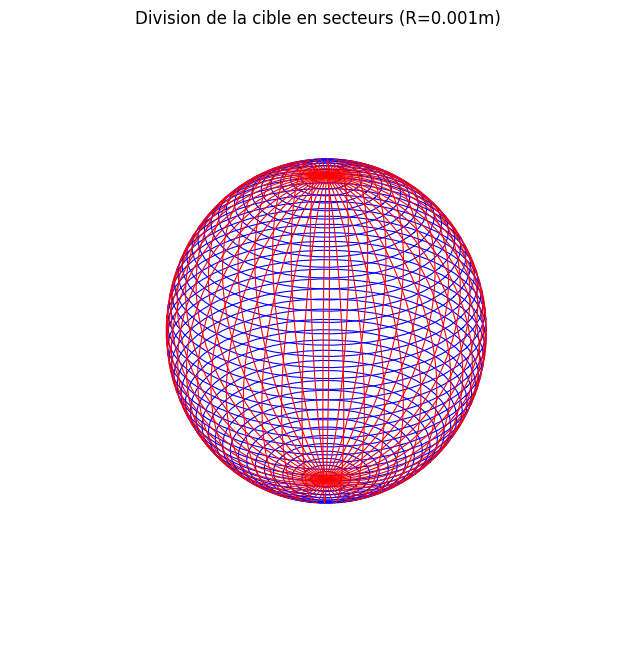

In [30]:
# 1. Création des secteurs (La grille est créée pour r=1 par défaut)
num_theta = 50
num_phi = 50
# On ne met PAS de radius ici, d'où l'erreur
sectors = rwhist.SphereSectors.factory(num_theta, num_phi) 

# 2. Affichage de la grille sur ta cible (Le radius se met ICI)
# La méthode plot_mesh remplace toutes tes boucles 'for' manuelles
fig, ax = sectors.plot_mesh(radius=TARGET_RADIUS)

# 3. Optionnel : On peut aussi afficher les centres des secteurs
# fig, ax = sectors.plot_centers(radius=TARGET_RADIUS, kwargs={'color': 'red', 's': 5})

ax.set_title(f"Division de la cible en secteurs (R={TARGET_RADIUS}m)")
plt.show()

Plot the center of each sectors on the mesh

Somme des aires calculées : 12.56637 (Attendu: 12.56637)


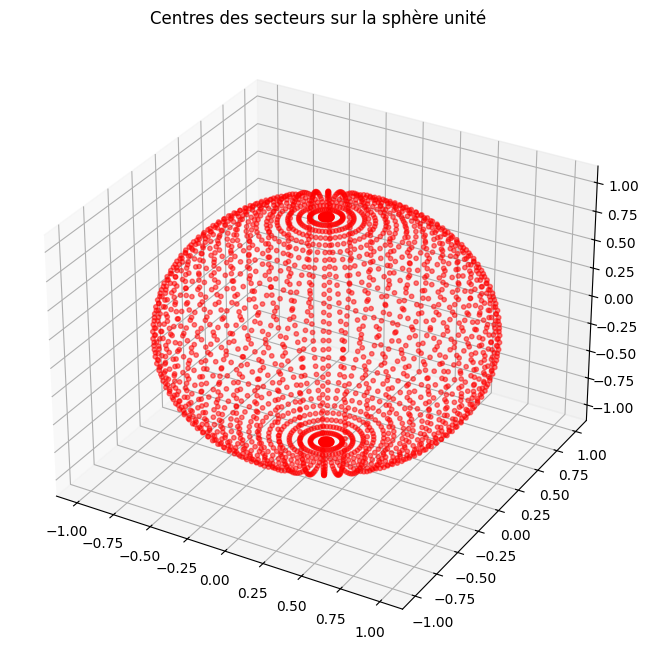

In [31]:
# 1. Calcul des aires et Vérification
# C'EST DÉJÀ FAIT ! factory() a déjà calculé 'sectors.areas' et vérifié la somme.
# Tu peux simplement vérifier la valeur si tu veux :
print(f"Somme des aires calculées : {np.sum(sectors.areas):.5f} (Attendu: {4*np.pi:.5f})")

# 2. Remplacement du scatter plot manuel
# La méthode plot_centers() fait déjà le 'coord.sph_to_cart' en interne.
# Tu peux passer tes paramètres graphiques (alpha, s, color) dans le dictionnaire 'kwargs'.
fig, ax = sectors.plot_centers(radius=1.0, kwargs={'alpha': 0.5, 's': 10, 'color': 'red'})

ax.set_title("Centres des secteurs sur la sphère unité")
plt.show()

## Histogram

In [32]:
def compute_histogram(hits, sectors):
    """
    Calcule l'histogramme de densité d'énergie déposée sur la sphère.
    Utilise l'objet SphereSectors pour le partitionnement et le calcul des aires.
    """
    # 1. Préparation des données physiques
    # On multiplie l'énergie par le cosinus d'incidence (Loi de Lambert)
    theta = hits['lat_rad'].values
    phi = hits['long_rad'].values
    weights = (hits['energy_weight'] * np.abs(hits['cs'])).values

    # 2. Histogramme 2D (Calcul brut par secteur)
    # On utilise les 'edges' (bords) définis dans ton objet sectors
    hs_raw, _, _ = np.histogram2d(
        theta, 
        phi, 
        bins=[sectors.theta_edges, sectors.phi_edges], 
        weights=weights
    )

    # 3. Calcul de la densité (Energie par unité de surface)
    # ATTENTION : on utilise sectors.areas (avec un 's') qui est le tableau 2D
    # calculé automatiquement par le module rwhist
    hs_density = hs_raw / sectors.areas

    # 4. Normalisation (0 à 1) pour le tracé de la carte de chaleur
    h_min, h_max = np.min(hs_density), np.max(hs_density)
    hs_norm = (hs_density - h_min) / (h_max - h_min) if h_max > h_min else hs_density

    # 5. Création du DataFrame de résultat (Aplatissement pour ARWEN/Plotly)
    return pd.DataFrame({
        'theta': sectors.mtheta.ravel(),
        'phi': sectors.mphi.ravel(),
        'area': sectors.areas.ravel(),
        'energy_raw': hs_raw.ravel(),
        'intensity': hs_density.ravel(),
        'intensity_norm': hs_norm.ravel()
    })

In [33]:
hits = total_impact[total_impact['cs'] < 0]

df_hist = compute_histogram(hits, sectors)

Import the 2D histogram into a csv file

In [45]:
from helpers import rwhist

# On reprend la colonne 'intensity' et on lui redonne sa forme 50x50
# .values transforme en NumPy, .reshape redonne la forme de la grille
histogram_numpy = df_hist['intensity'].values.reshape(sectors.mtheta.shape)


# 'hs_density' est la matrice 2D (50x50) calculée dans compute_histogram
# 'sectors' contient les bords (edges) de ta grille
rwhist.write_histogram(
    sectors.theta_edges, 
    sectors.phi_edges, 
    histogram_numpy, 
    "omega60_illumination_map.csv"
)

print("Fichier exporté pour le calcul des harmoniques sphériques.")

Fichier exporté pour le calcul des harmoniques sphériques.


## Showing 3D histogram

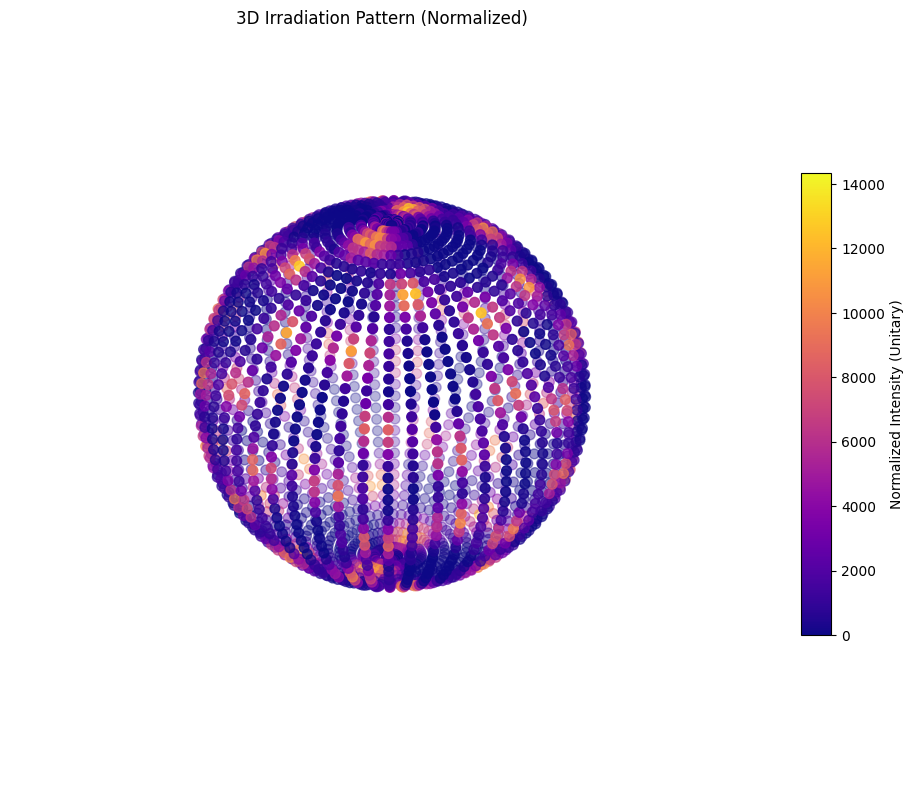

In [34]:
fig = plt.figure(figsize=(12, 12)) # Un peu plus petit pour que ce soit plus fluide
ax = fig.add_subplot(111, projection='3d')

# On récupère les valeurs (hs_unit est la normalisation physique que ton maître veut)
hs = df_hist['intensity'].values

# Conversion en coordonnées Cartésiennes
xs, ys, zs = coord.sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

X, Y, Z = xs.ravel(), ys.ravel(), zs.ravel()
C = hs.ravel() 

# --- LA CORRECTION EST ICI ---
# On force l'échelle de couleurs à coller au minimum et au maximum de tes données
# C'est ce qui transforme le "tout bleu" en "taches colorées"
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=50, vmin=C.min(), vmax=C.max())

# Colorbar (on l'affine un peu)
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=15)
cb.set_label("Normalized Intensity (Unitary)")

ax.set_box_aspect([1, 1, 1])
ax.set_title("3D Irradiation Pattern (Normalized)")
ax.set_axis_off()

plt.show()

## Integrated intensity

In [41]:
def compute_theta_distribution(df_final_map):
    """
    Intègre I(theta, phi) sur phi pour obtenir le profil moyen I(theta).
    Utilise la colonne 'intensity' (W/m2) du nouveau DataFrame.
    """
    # 1. On regroupe par theta et on calcule la moyenne de l'intensité
    # On utilise 'intensity' car c'est ta valeur physique finale
    theta_profile = df_final_map.groupby('theta')['intensity'].mean().reset_index()
    
    # 2. Renommer pour la clarté
    theta_profile.columns = ['theta_rad', 'intensity_avg']
    
    # 3. Conversion en degrés pour le graphique
    theta_profile['theta_deg'] = np.degrees(theta_profile['theta_rad'])
    
    # Optionnel : Normalisation du profil (pour voir les variations en %)
    avg_total = theta_profile['intensity_avg'].mean()
    theta_profile['variation_pct'] = (theta_profile['intensity_avg'] / avg_total - 1) * 100
    
    return theta_profile

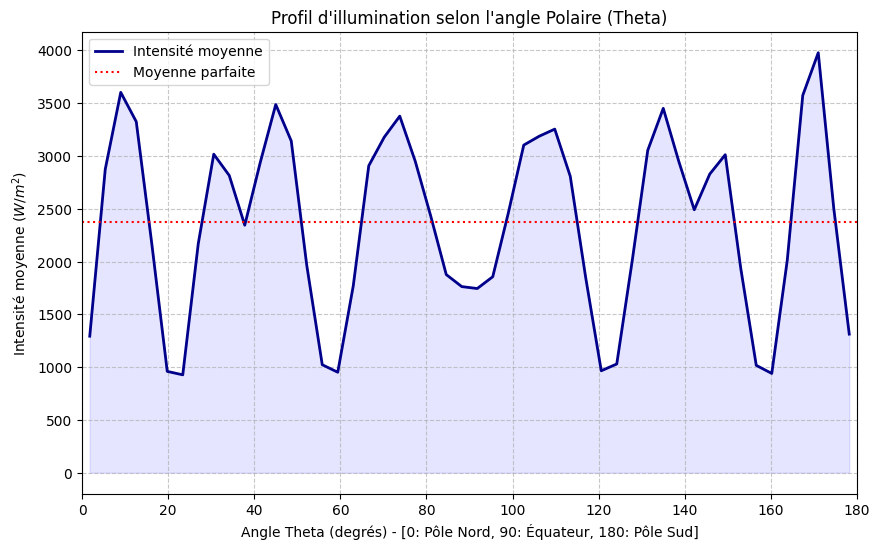

In [43]:
# --- EXÉCUTION ---
# df_final_map est le résultat de ta fonction compute_histogram
df_theta = compute_theta_distribution(df_hist)

# --- VISUALISATION ---
plt.figure(figsize=(10, 6))

# Tracé de la courbe
plt.plot(df_theta['theta_deg'], df_theta['intensity_avg'], color='darkblue', lw=2, label='Intensité moyenne')
plt.fill_between(df_theta['theta_deg'], df_theta['intensity_avg'], color='blue', alpha=0.1)

# Esthétique
plt.title("Profil d'illumination selon l'angle Polaire (Theta)")
plt.xlabel("Angle Theta (degrés) - [0: Pôle Nord, 90: Équateur, 180: Pôle Sud]")
plt.ylabel("Intensité moyenne ($W/m^2$)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 180)

# Ajout d'une ligne horizontale pour l'intensité moyenne parfaite
plt.axhline(df_theta['intensity_avg'].mean(), color='red', linestyle=':', label='Moyenne parfaite')

plt.legend()
plt.show()

### 

## Pyvista representation 

In [37]:
import nest_asyncio

# On applique le patch une seule fois au début
nest_asyncio.apply()

def plot_omega_histogram_pyvista(sectors, hs, target_radius=0.001, cmap='plasma', filename="simulation_omega60.html"):
    """
    Affiche l'histogramme sphérique d'énergie sur la cible et exporte en HTML.
    """
    # 1. Conversion des coordonnées
    display_radius = target_radius * 1.05 
    xs, ys, zs = coord.sph_to_cart(display_radius, sectors.mtheta, sectors.mphi)

    # 2. Préparation des données
    points = np.column_stack([xs.ravel(), ys.ravel(), zs.ravel()])
    densities = hs.ravel()

    # 3. Création des objets PyVista
    point_cloud = pv.PolyData(points)
    point_cloud["Irradiance"] = densities
    target_sphere = pv.Sphere(radius=target_radius, center=(0, 0, 0), theta_resolution=100, phi_resolution=100)

    # 4. Configuration du Plotter
    pv.set_jupyter_backend('trame')
    plotter = pv.Plotter(window_size=[800, 600])
    plotter.background_color = "white"

    # Ajout des éléments à la scène
    plotter.add_mesh(target_sphere, color="lightgrey", opacity=0.3, label="Cible")
    plotter.add_mesh(
        point_cloud,
        scalars="Irradiance",
        cmap=cmap,
        render_points_as_spheres=True,
        point_size=10, 
        show_scalar_bar=True,
        scalar_bar_args={"title": "Energie normalisée (J/mm2)"}
    )

    plotter.add_title("Distribution Sphérique de l'Energie - OMEGA-60")
    plotter.add_legend()
    plotter.view_isometric()

    # --- ÉTAPE CRUCIALE : EXPORT AVANT LE SHOW ---
    # On utilise l'argument 'filename' passé à la fonction
    plotter.export_html(filename) 
    print(f"Fichier interactif sauvegardé : {filename}")

    # Affichage dans le Notebook
    plotter.show()

# --- UTILISATION ---
plot_omega_histogram_pyvista(sectors, hs, target_radius=TARGET_RADIUS, cmap='plasma', filename="simulation_omega60.html")

Fichier interactif sauvegardé : simulation_omega60.html


Widget(value='<iframe src="http://localhost:53865/index.html?ui=P_0x16a5c0ed110_0&reconnect=auto" class="pyvis…